# ***Question 4: SVD Spectrum***

## ***Setup***

### ***Hugging Face Login***

In [1]:
import os
from pathlib import Path

from huggingface_hub import login

HF_TOKEN_NAME = 'HF_TOKEN'
ENV_FILE_NAME = '.env'


def read_kaggle_token(*, label: str) -> str | None:
    try:
        from kaggle_secrets import UserSecretsClient
    except ImportError:
        return None
    try:
        return UserSecretsClient().get_secret(label)
    except Exception:
        return None


def read_env_file_token(*, start: Path, name: str) -> str | None:
    from dotenv import dotenv_values

    for directory in (start, *start.parents):
        env_file = directory / ENV_FILE_NAME
        if env_file.is_file():
            return dotenv_values(env_file).get(name)
    return None


token = (
    os.environ.get(HF_TOKEN_NAME)
    or read_kaggle_token(label=HF_TOKEN_NAME)
    or read_env_file_token(
        start=Path.cwd(),
        name=HF_TOKEN_NAME,
    )
)
if token:
    login(token=token)
    print('Hugging Face login: OK')
else:
    print('HF_TOKEN not found; continuing with cached credentials if any.')

Hugging Face login: OK


### ***Model Loading***

In [2]:
import torch
from transformers import AutoModelForCausalLM
import matplotlib.pyplot as plt

model = AutoModelForCausalLM.from_pretrained('meta-llama/Llama-3.2-1B',)

Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

## ***SVD Analysis***

### ***Spectrum Functions***

In [3]:
from dataclasses import dataclass

import pandas as pd

LAYER_INDICES = (0, 7, 15)
ENERGY_THRESHOLD_PERCENT = 50.0
PLOT_LIMIT = 200
PERCENT_SCALE = 100.0


@dataclass(frozen=True, slots=True)
class LayerSpectrum:
    layer_index: int
    weight_shape: tuple[int, int]
    singular_values: torch.Tensor
    cumulative_energy_percent: torch.Tensor
    minimum_rank: int


def compute_cumulative_energy(*, singular_values: torch.Tensor) -> torch.Tensor:
    energy = singular_values**2
    return torch.cumsum(energy, dim=0) / torch.sum(energy) * PERCENT_SCALE


def find_minimum_rank(
    *,
    cumulative_energy_percent: torch.Tensor,
    threshold_percent: float,
) -> int:
    reached = torch.nonzero(cumulative_energy_percent >= threshold_percent)
    return int(reached[0].item()) + 1 if len(reached) else len(cumulative_energy_percent)


@torch.no_grad()
def analyse_q_proj(
    *,
    model: torch.nn.Module,
    layer_index: int,
    threshold_percent: float,
) -> LayerSpectrum:
    q_weight = model.model.layers[layer_index].self_attn.q_proj.weight.detach()
    _, singular_values, _ = torch.linalg.svd(
        q_weight.float(),
        full_matrices=False,
    )
    cumulative_energy_percent = compute_cumulative_energy(singular_values=singular_values)
    return LayerSpectrum(
        layer_index=layer_index,
        weight_shape=(int(q_weight.shape[0]), int(q_weight.shape[1])),
        singular_values=singular_values,
        cumulative_energy_percent=cumulative_energy_percent,
        minimum_rank=find_minimum_rank(
            cumulative_energy_percent=cumulative_energy_percent,
            threshold_percent=threshold_percent,
        ),
    )

### ***Minimum Target Rank***

In [4]:
spectra = [
    analyse_q_proj(
        model=model,
        layer_index=layer_index,
        threshold_percent=ENERGY_THRESHOLD_PERCENT,
    )
    for layer_index in LAYER_INDICES
]

minimum_rank_table = pd.DataFrame(
    {f'Layer {spectrum.layer_index}': [spectrum.minimum_rank] for spectrum in spectra},
    index=['Minimum Target Rank for query projection weights'],
)
display(minimum_rank_table)

details = pd.DataFrame(
    [
        {
            'layer': spectrum.layer_index,
            'weight_shape': spectrum.weight_shape,
            'full_rank': len(spectrum.singular_values),
            'minimum_rank_50%': spectrum.minimum_rank,
            'rank_ratio_%': round(PERCENT_SCALE * spectrum.minimum_rank / len(spectrum.singular_values), 2),
            'sigma_1': round(float(spectrum.singular_values[0]), 3),
            f'sigma_{PLOT_LIMIT}': round(float(spectrum.singular_values[PLOT_LIMIT - 1]), 3),
            f'energy_top{PLOT_LIMIT}_%': round(float(spectrum.cumulative_energy_percent[PLOT_LIMIT - 1]), 2),
        }
        for spectrum in spectra
    ]
)
display(details)

,Layer 0,Layer 7,Layer 15
Minimum Target Rank for query projection weights,62,120,84


,layer,weight_shape,full_rank,minimum_rank_50%,rank_ratio_%,sigma_1,sigma_200,energy_top200_%
0,0,"(2048, 2048)",2048,62,3.03,31.358,2.426,71.24
1,7,"(2048, 2048)",2048,120,5.86,10.337,1.976,63.54
2,15,"(2048, 2048)",2048,84,4.10,12.881,1.704,68.84


## ***Visualization***

### ***Plot Functions***

In [5]:
import matplotlib
from cycler import cycler

ACADEMIC_PALETTE = ('#4C72B0', '#55A868', '#DD8452', '#C44E52', '#8172B3', '#937860')
ACADEMIC_MARKERS = ('o', 's', '^', 'D', 'v', 'P')
LAYER_COLOURS = ACADEMIC_PALETTE[2:5]
LAYER_MARKERS = ACADEMIC_MARKERS[2:5]
THRESHOLD_COLOUR = '#7F7F7F'
FIGURE_SIZE = (8.0, 3.2)
FIGURE_DPI = 300
DISPLAY_DPI = 160
OUTPUT_DIR_NAME = 'outputs'
FIGURE_SUBDIR = 'q4_figures'


def find_output_dir(*, start: Path) -> Path:
    for directory in (start, *start.parents):
        if (directory / OUTPUT_DIR_NAME).is_dir():
            return directory / OUTPUT_DIR_NAME
    return start / OUTPUT_DIR_NAME


FIGURE_DIR = find_output_dir(start=Path.cwd()) / FIGURE_SUBDIR


def apply_academic_style() -> None:
    plt.rcParams.update(
        {
            'font.family': 'serif',
            'font.size': 9,
            'axes.labelsize': 9,
            'legend.fontsize': 8,
            'xtick.labelsize': 8,
            'ytick.labelsize': 8,
            'axes.spines.top': False,
            'axes.spines.right': False,
            'axes.prop_cycle': cycler(color=ACADEMIC_PALETTE, marker=ACADEMIC_MARKERS),
            'grid.color': '#DDDDDD',
            'grid.linewidth': 0.5,
            'lines.linewidth': 1.5,
            'lines.markersize': 4,
            'legend.frameon': False,
            'figure.dpi': DISPLAY_DPI,
            'savefig.dpi': FIGURE_DPI,
            'savefig.bbox': 'tight',
            'pdf.fonttype': 42,
        }
    )


def save_figure(
    *,
    figure: plt.Figure,
    path: Path,
) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    for suffix in ('.pdf', '.png'):
        figure.savefig(path.with_suffix(suffix))


def plot_singular_values(
    *,
    singular_values: torch.Tensor,
    colour: str,
    label: str,
) -> plt.Figure:
    values = singular_values.cpu().numpy()
    indices = range(1, len(values) + 1)
    figure, axis = plt.subplots(figsize=FIGURE_SIZE)
    axis.bar(
        indices,
        values,
        width=1.0,
        color=colour,
        linewidth=0.0,
        label=label,
    )
    axis.set_xlabel('Singular value index')
    axis.set_ylabel('Singular value magnitude')
    axis.set_xlim(0.5, len(values) + 0.5)
    axis.legend(loc='upper right')
    return figure


def plot_cumulative_energy(
    *,
    cumulative_energy_percent: torch.Tensor,
    threshold_percent: float,
    minimum_rank: int,
    colour: str,
    marker: str,
    label: str,
) -> plt.Figure:
    values = cumulative_energy_percent.cpu().numpy()
    ranks = range(1, len(values) + 1)
    figure, axis = plt.subplots(figsize=FIGURE_SIZE)
    axis.plot(
        ranks,
        values,
        color=colour,
        marker=marker,
        markevery=max(1, len(values) // 10),
        label=label,
    )
    axis.axhline(
        threshold_percent,
        color=THRESHOLD_COLOUR,
        linestyle='--',
        linewidth=0.8,
        label=f'{threshold_percent:.0f}% energy',
    )
    if minimum_rank <= len(values):
        axis.axvline(
            minimum_rank,
            color=THRESHOLD_COLOUR,
            linestyle=':',
            linewidth=0.8,
        )
        axis.annotate(
            f'r = {minimum_rank}',
            xy=(minimum_rank, threshold_percent),
            xytext=(4, -12),
            textcoords='offset points',
            fontsize=7,
        )
    axis.set_xlabel('Target rank')
    axis.set_ylabel('Cumulative energy (%)')
    axis.set_xlim(1, len(values))
    axis.set_ylim(0, 100)
    axis.yaxis.grid(True)
    axis.set_axisbelow(True)
    axis.legend(loc='lower right')
    return figure

### ***Spectrum Charts***

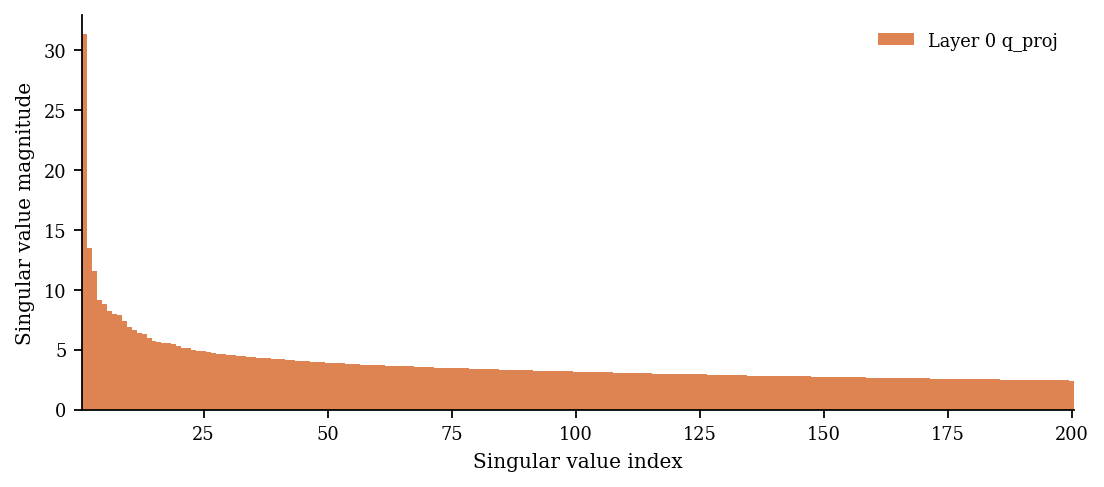

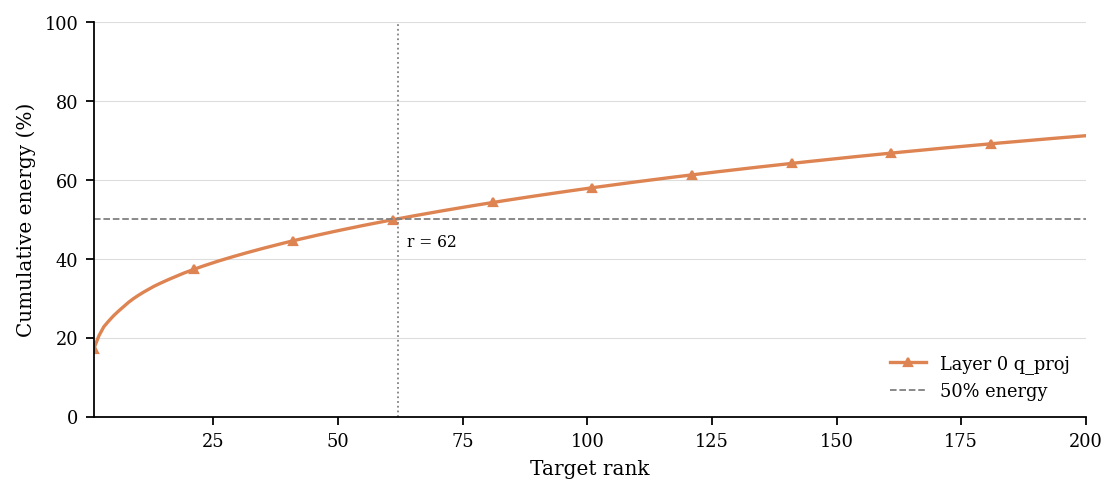

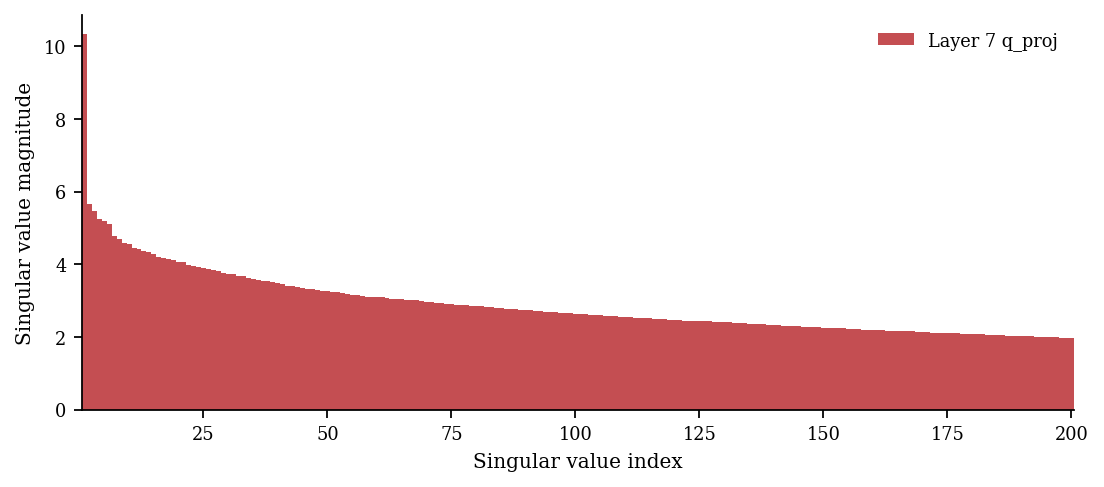

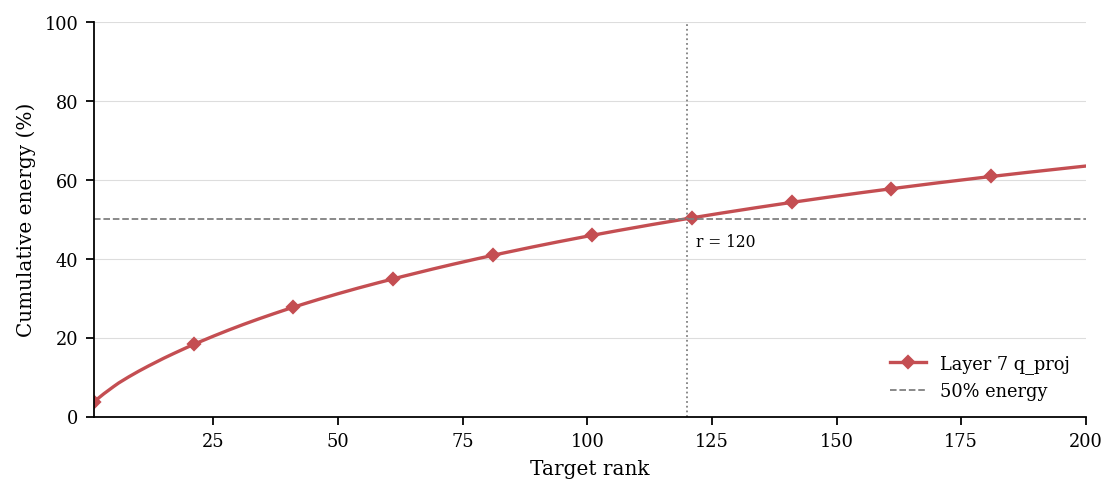

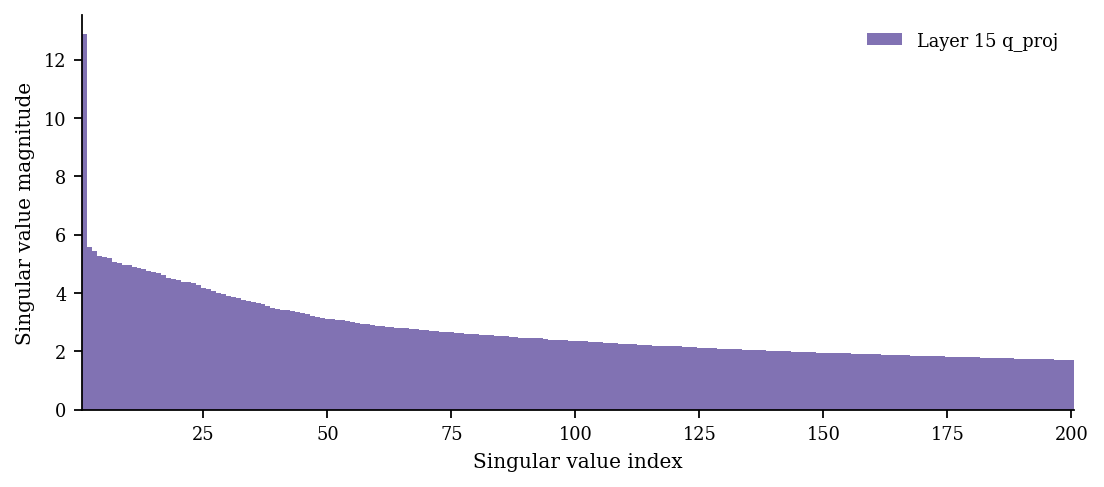

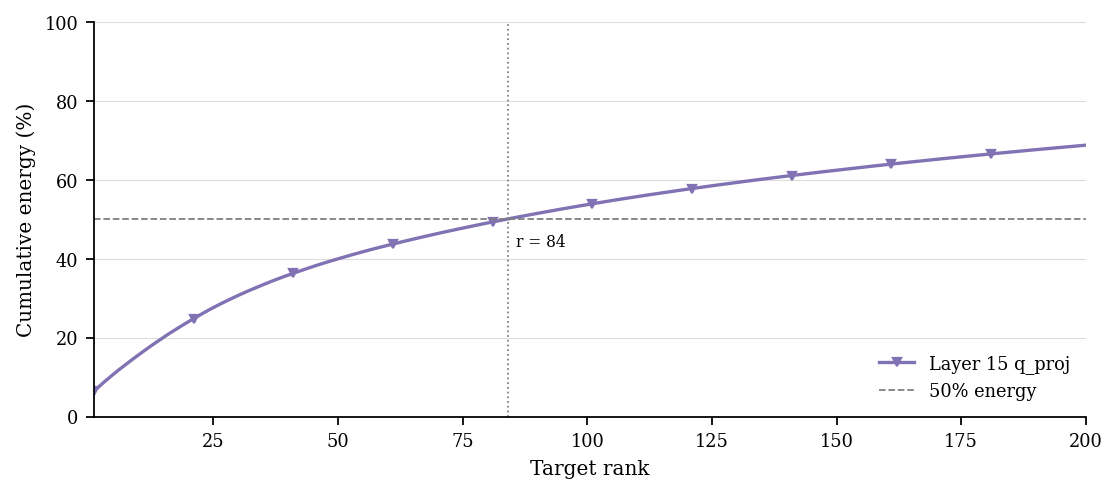

Figures saved to /home/longpm/works/knowledge/big-data-nycu/hw1/outputs/q4_figures


In [6]:
apply_academic_style()
for position, spectrum in enumerate(spectra):
    label = f'Layer {spectrum.layer_index} q_proj'
    colour = LAYER_COLOURS[position]

    bar_figure = plot_singular_values(
        singular_values=spectrum.singular_values[:PLOT_LIMIT],
        colour=colour,
        label=label,
    )
    save_figure(
        figure=bar_figure,
        path=FIGURE_DIR / f'q4_singular_values_layer{spectrum.layer_index}',
    )
    plt.show()

    line_figure = plot_cumulative_energy(
        cumulative_energy_percent=spectrum.cumulative_energy_percent[:PLOT_LIMIT],
        threshold_percent=ENERGY_THRESHOLD_PERCENT,
        minimum_rank=spectrum.minimum_rank,
        colour=colour,
        marker=LAYER_MARKERS[position],
        label=label,
    )
    save_figure(
        figure=line_figure,
        path=FIGURE_DIR / f'q4_cumulative_energy_layer{spectrum.layer_index}',
    )
    plt.show()

print('Figures saved to', FIGURE_DIR)